# timeSeries data
time dependent data -- prediction on time series data is called forecasting
diffewncw btw regression and forecasting 
frequency - 
horizon - 
types of forecasting -----
1) Quantitative ---
2) Quanlitative --- expert - surveys of a product - marketing(forecasting how much product will be sellled)

3 importatnt of components of time series----
trend - increase and decrease in data(oveRALL trend)
seasonality - pattern which repeats over time (ice cream sells data)
noise - randomness in data(if we remove trend and seasonality from data then noise remains)it should be straight line 

properties of data----
data can be additive or multiplicative  

data should be stationary before applying models()

lag - we dont have anything in data so the value is influenced by previous value that why we use lag






In [1]:
import pandas as pd
import numpy as np
import datetime

In [2]:
df = pd.read_excel('complain1.xlsx',index_col=0)
df = df[['Created Date' ,'Category']]
df

,Created Date,Category
0,31-05-2025,Civil
1,31-05-2025,Electrical
2,31-05-2025,Civil
3,31-05-2025,Civil
4,31-05-2025,Electrical
...,...,...
3045,02-01-2025,Horticulture
3046,02-01-2025,Civil
3047,01-01-2025,Civil
3048,01-01-2025,Civil


In [3]:
df['Created Date'] = pd.to_datetime(df['Created Date'])

C:\Users\pc\AppData\Local\Temp\ipykernel_22368\1404928464.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Created Date'] = pd.to_datetime(df['Created Date'])


In [4]:
df['Created Date']

0      2025-05-31
1      2025-05-31
2      2025-05-31
3      2025-05-31
4      2025-05-31
          ...    
3045   2025-01-02
3046   2025-01-02
3047   2025-01-01
3048   2025-01-01
3049   2025-01-01
Name: Created Date, Length: 3045, dtype: datetime64[ns]

In [5]:
df.set_index('Created Date' , inplace=True)

In [6]:
weekly_complaints = df.resample('W').size().reset_index(name='Weekly Complaints')
weekly_complaints.set_index('Created Date' , inplace=True)
print(weekly_complaints)

              Weekly Complaints
Created Date                   
2025-01-05                   18
2025-01-12                   45
2025-01-19                   39
2025-01-26                   86
2025-02-02                  133
2025-02-09                  101
2025-02-16                  116
2025-02-23                  126
2025-03-02                  153
2025-03-09                  140
2025-03-16                  140
2025-03-23                  172
2025-03-30                  157
2025-04-06                  189
2025-04-13                  185
2025-04-20                  188
2025-04-27                  218
2025-05-04                  154
2025-05-11                  144
2025-05-18                  162
2025-05-25                  208
2025-06-01                  171


In [7]:
daily_complaints = df.resample('D').size().reset_index(name='DailyComplaints')
daily_complaints

,Created Date,DailyComplaints
0,2025-01-01,3
1,2025-01-02,5
2,2025-01-03,2
3,2025-01-04,5
4,2025-01-05,3
...,...,...
146,2025-05-27,16
147,2025-05-28,31
148,2025-05-29,32
149,2025-05-30,24


In [8]:
monthly_complaints = df.resample('M').size().reset_index(name='Monthly Complaints')
print(monthly_complaints)


  Created Date  Monthly Complaints
0   2025-01-31                 298
1   2025-02-28                 492
2   2025-03-31                 665
3   2025-04-30                 827
4   2025-05-31                 763


C:\Users\pc\AppData\Local\Temp\ipykernel_22368\1930328326.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_complaints = df.resample('M').size().reset_index(name='Monthly Complaints')


In [9]:
from statsmodels.tsa.stattools import adfuller

# Assuming 'weekly_complaints' is already computed
weekly_counts = weekly_complaints['Weekly Complaints']

# ADF Test
result = adfuller(weekly_counts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -2.4653354355905353
p-value: 0.12413797306166374


In [10]:
weekly_diff = weekly_counts.diff().dropna()

# ADF Test again
result = adfuller(weekly_diff)
print("After differencing - ADF Statistic:", result[0])
print("p-value:", result[1])


After differencing - ADF Statistic: -5.48977374499039
p-value: 2.1885205838876847e-06


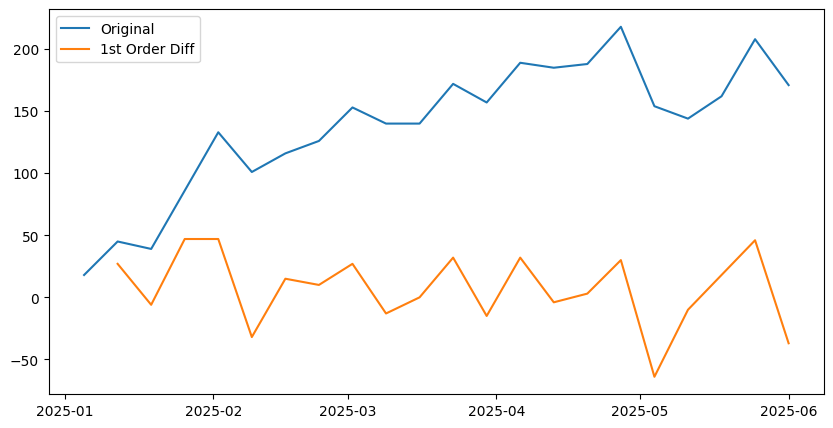

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(weekly_counts, label='Original')
plt.plot(weekly_diff, label='1st Order Diff')
plt.legend()
plt.show()

In [12]:
from pmdarima import auto_arima

model = auto_arima(weekly_diff, seasonal=True, 
                   stepwise=True, trace=True,
                   max_p=3, max_q=3,
                   max_P=2, max_Q=2,
                   d=None, D=None,
                   start_p=0, start_q=0,
                   start_P=0, start_Q=0,
                   error_action='ignore', suppress_warnings=True)
print(model.summary())


c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:1

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=204.851, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=205.094, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=204.063, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=204.147, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=205.980, Time=0.10 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=205.926, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=207.354, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=205.158, Time=0.05 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 0.344 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   21
Model:               SARIMAX(0, 0, 1)   Log Likelihood                 -99.032
Date:                Mon, 22 Sep 2025   AIC                            204.063
Time:                        17:45:45   BIC 

c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [13]:
train = weekly_diff[:-10]
test = weekly_diff[-10:]


In [14]:
test

Created Date
2025-03-30   -15.0
2025-04-06    32.0
2025-04-13    -4.0
2025-04-20     3.0
2025-04-27    30.0
2025-05-04   -64.0
2025-05-11   -10.0
2025-05-18    18.0
2025-05-25    46.0
2025-06-01   -37.0
Name: Weekly Complaints, dtype: float64

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


In [ ]:

arima_model = ARIMA(train, order=(0,0,1))
arima_result = arima_model.fit()

# Forecast
arima_forecast = arima_result.forecast(steps=10)


c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [17]:
# Seasonal order: (P,D,Q,s)
# For weekly data with yearly seasonality: s=52
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,4) )
sarima_result = sarima_model.fit()

# Forecast
sarima_forecast = sarima_result.forecast(steps=10)


c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


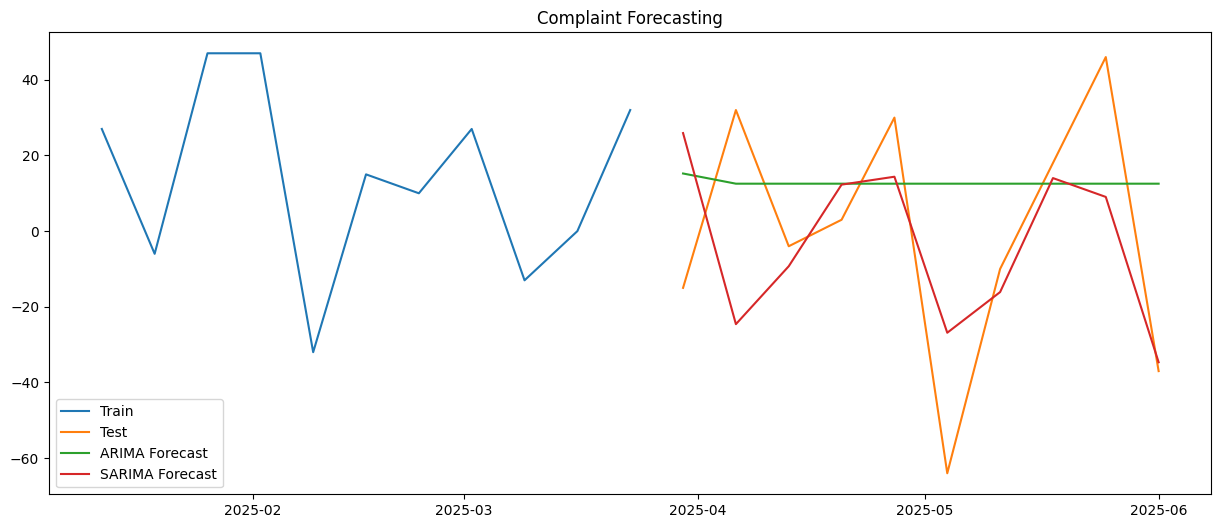

In [18]:
plt.figure(figsize=(15,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')
plt.legend()
plt.title("Complaint Forecasting")
plt.show()


In [19]:
print("ARIMA MSE:", mean_squared_error(test, arima_forecast))
print("SARIMA MSE:", mean_squared_error(test, sarima_forecast))


ARIMA MSE: 1193.0908824241667
SARIMA MSE: 803.9171782867904


In [20]:
naive_forecast = [train.iloc[-1]] * len(test)
naive_mse = mean_squared_error(test, naive_forecast)
naive_mse

2048.3

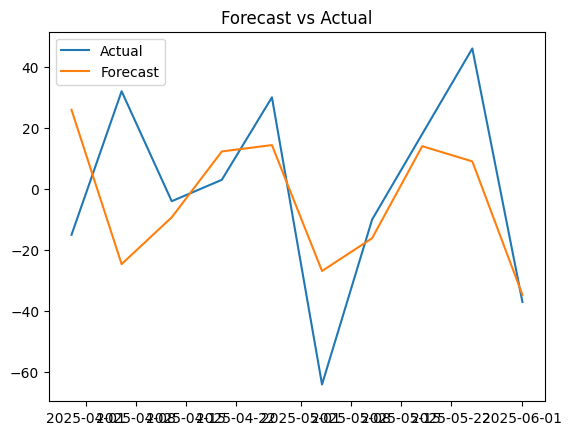

In [21]:
import matplotlib.pyplot as plt

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_forecast, label="Forecast")
plt.legend()
plt.title("Forecast vs Actual")
plt.show()


In [22]:
sarima_model2 = SARIMAX(weekly_diff , order=(1,1,1), seasonal_order=(1,1,1,4) )
sarima_result2 = sarima_model2.fit()

# Forecast
sarima_forecast2 = sarima_result.forecast(steps=10)


c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [23]:
# Get the last date in your original series
last_date = weekly_diff.index[-1]

# Create 10 future dates (weekly frequency)
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=10, freq='W')

# Convert forecast to DataFrame
forecast_df = pd.DataFrame({
    'date': future_dates,
    'predicted_diff_complaints': sarima_forecast2
})
forecast_df.set_index('date', inplace=True)
forecast_df

,predicted_diff_complaints
date,
2025-06-08,25.910315
2025-06-15,-24.590099
2025-06-22,-9.282893
2025-06-29,12.282876
2025-07-06,14.375617
2025-07-13,-26.855633
2025-07-20,-16.110285
2025-07-27,14.013974
2025-08-03,9.034331


In [24]:
# Ensure datetime index
weekly_complaints.index = pd.to_datetime(weekly_complaints.index)

# Get last value from original series
last_actual = weekly_complaints.iloc[-1][0]
print(last_actual)

# Reverse the differencing
forecast_df['predicted_actual'] = forecast_df['predicted_diff_complaints'].cumsum() + last_actual

forecast_df


C:\Users\pc\AppData\Local\Temp\ipykernel_22368\2270827689.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_actual = weekly_complaints.iloc[-1][0]


171


,predicted_diff_complaints,predicted_actual
date,,
2025-06-08,25.910315,196.910315
2025-06-15,-24.590099,172.320217
2025-06-22,-9.282893,163.037323
2025-06-29,12.282876,175.320199
2025-07-06,14.375617,189.695816
2025-07-13,-26.855633,162.840184
2025-07-20,-16.110285,146.729898
2025-07-27,14.013974,160.743873
2025-08-03,9.034331,169.778203


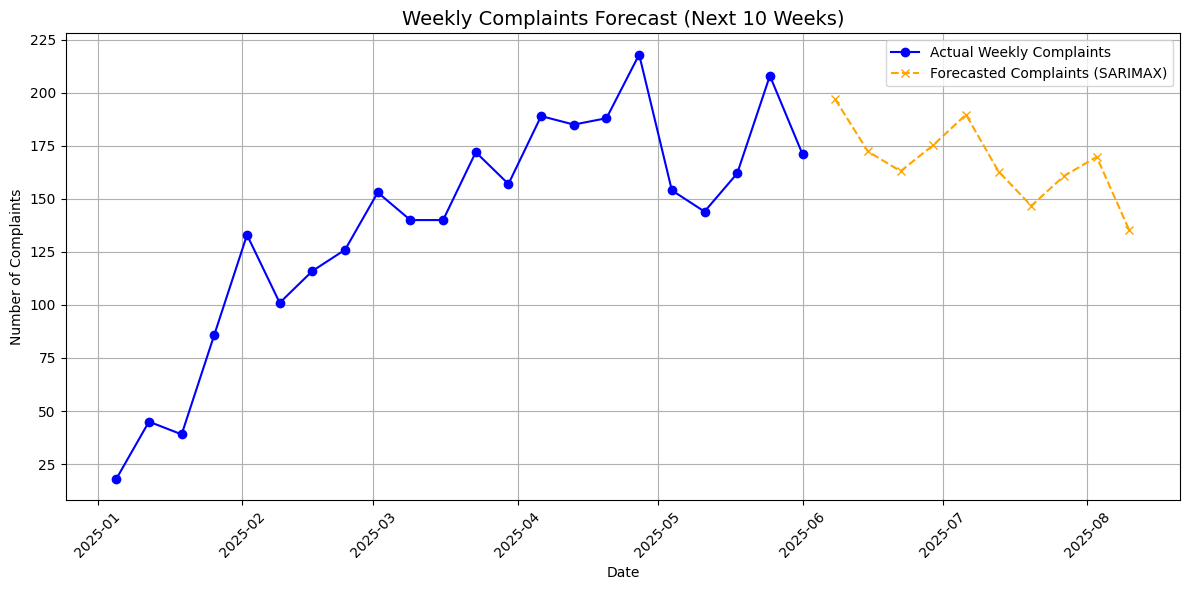

In [25]:
import matplotlib.pyplot as plt

# Ensure both series are aligned on datetime index
weekly_complaints.index = pd.to_datetime(weekly_complaints.index)
forecast_df.index = pd.to_datetime(forecast_df.index)

# Plot the original complaint series
plt.figure(figsize=(12, 6))
plt.plot(weekly_complaints, label='Actual Weekly Complaints', color='blue', marker='o')

# Plot the forecasted actuals
plt.plot(forecast_df['predicted_actual'], label='Forecasted Complaints (SARIMAX)', color='orange', linestyle='--', marker='x')

# Chart styling
plt.title('Weekly Complaints Forecast (Next 10 Weeks)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


In [31]:
forecast_df.predicted_actual

date
2025-06-08    196.910315
2025-06-15    172.320217
2025-06-22    163.037323
2025-06-29    175.320199
2025-07-06    189.695816
2025-07-13    162.840184
2025-07-20    146.729898
2025-07-27    160.743873
2025-08-03    169.778203
2025-08-10    135.120816
Name: predicted_actual, dtype: float64